# Phase 5 — Final Analysis

Cross-phase summary of the full experimental study (Phases 1-4): FP32/INT8 rankings, quantization accuracy-drop analysis, model size comparison (with Pareto frontier), training time comparison, latency comparison, a Winograd-compatibility discussion, and final conclusions/recommendations.

Pure analysis notebook — no training/QAT imports, loads directly from each phase's saved `final_comparison.csv` / `*_summary.json` / `experiment_summary.json` (same pattern as `results_analysis.ipynb`, extended to include Phase 4).

## Configuration

In [10]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def find_project_root(start: Path | None = None):
    '''Find the repository root by walking upward until the expected project markers appear.'''
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / 'README.md').exists() and (candidate / 'models').exists() and (candidate / 'results').exists():
            return candidate
    return start


project_root = find_project_root()

PHASE_DIRS = {
    'Phase 1 - Baselines':          project_root / 'results' / 'baselines_qat_phase1',
    'Phase 2 - AlexNet Variants':   project_root / 'results' / 'alexnet_qat_phase2',
    'Phase 3 - Compensation':       project_root / 'results' / 'compensation_phase3',
    'Phase 4 - Final Architecture': project_root / 'results' / 'final_architecture_phase4',
}
COMPRESSION_DIR = project_root / 'results' / 'compression_phase4_1'

RESULTS_DIR = project_root / 'results' / 'final_analysis_phase5'
FIGURES_DIR = project_root / 'results' / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11})

phases = list(PHASE_DIRS.keys())
PHASE_COLORS = {p: plt.cm.tab10.colors[i] for i, p in enumerate(phases)}


def annotate_labels(ax, df, x_col, y_col, label_col, fontsize=7, boxed=False):
    '''Annotate scatter points with labels, cycling offsets (sorted by x) to reduce overlap.'''
    offsets = [(6, 6), (6, -12), (-48, 6), (6, 18), (-48, -12)]
    bbox_kw = dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.65) if boxed else None
    for i, (_, row) in enumerate(df.sort_values(x_col).iterrows()):
        dx, dy = offsets[i % len(offsets)]
        ax.annotate(row[label_col], (row[x_col], row[y_col]),
                    xytext=(dx, dy), textcoords='offset points', fontsize=fontsize,
                    alpha=0.85, bbox=bbox_kw)

## Load Data

In [11]:
def load_comparison_data(phase_dirs):
    '''Load final_comparison.csv from each phase dir.'''
    frames = []
    for label, d in phase_dirs.items():
        csv = d / 'final_comparison.csv'
        if not csv.exists():
            print(f'[skip] {label}: no final_comparison.csv')
            continue
        df = pd.read_csv(csv)
        df['phase'] = label
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_model_summaries(phase_dirs):
    '''Load per-model *_summary.json files (skips experiment_summary.json and executive_summary.json).'''
    rows = []
    for label, d in phase_dirs.items():
        for f in sorted(d.glob('*_summary.json')):
            if f.name in ('experiment_summary.json', 'executive_summary.json'):
                continue
            with open(f) as fp:
                data = json.load(fp)
            data['phase'] = label
            rows.append(data)
    return pd.DataFrame(rows) if rows else pd.DataFrame()


df_comp = load_comparison_data(PHASE_DIRS)
df_summ = load_model_summaries(PHASE_DIRS)
print(f'Comparison rows : {len(df_comp):3d}  (phases: {df_comp["phase"].nunique() if not df_comp.empty else 0})')
print(f'Per-model JSONs : {len(df_summ):3d}')

Comparison rows :  45  (phases: 4)
Per-model JSONs :  26


In [12]:
# All-model comparison table (raw final_comparison.csv rows, FP32 + INT8)
if not df_comp.empty:
    df_comp.sort_values(['phase', 'model']).reset_index(drop=True)

## Winograd Kernel-Size Mapping

Hand-curated from the per-model architecture notes already documented in `ideas/MODELS.md` (several entries explicitly call out Winograd compatibility) and `models/final_architecture.py` (Phase 4 hybrids are built from Phase 3's 3x3-based mechanisms). `winograd_friendly = True` means the dominant conv kernel is a standard Winograd tile size (3x3, with 1x1 for pure channel mixing); `False` marks even kernels (2x2), asymmetric factorized kernels, or large pretrained-model stem kernels that break standard Winograd tiling.

In [13]:
# model_name -> (winograd_friendly, dominant_kernel, note)
WINOGRAD_INFO = {
    'alexnet_tv':          (False, '11x11/5x5/3x3',    'Large pretrained AlexNet kernels'),
    'vgg_style':           (True,  '3x3',               'Pure stacked 3x3'),
    'resnet18_tv':         (False, '7x7 stem + 3x3',    '7x7 stem breaks uniform tiling'),
    'mobilenetv2':         (False, '3x3 dw + 1x1 pw',   'Depthwise 3x3 not a standard Winograd target'),
    'alexnet_3x3':         (True,  '3x3',               'Uniform 3x3 restriction'),
    'alexnet_2x2':         (False, '2x2',                'Even kernel, incompatible with Winograd'),
    'alexnet_stacked':     (True,  '3x3 (stacked)',     'Stacked 3x3'),
    'alexnet_mixed':       (False, '3x3 + 2x2',         'Mixed - partially incompatible (2x2 layers)'),
    'alexnet_small_kernel':(True,  '3x3',               'Narrow-channel 3x3, GAP head'),
    'alexnet_bottleneck':  (True,  '1x1 + 3x3',         'Bottleneck reduce/expand around 3x3'),
    'alexnet_factorized':  (False, '1x3 + 3x1',         'Asymmetric factorized, non-standard tile'),
    'alexnet_groupconv':   (True,  '3x3 (grouped)',     'Grouped 3x3'),
    'alexnet_depthwisesep':(True,  '3x3 dw + 1x1 pw',   '3x3 depthwise + 1x1 pointwise'),
    'alexnet_residual':    (True,  '3x3',               '3x3 convs in residual blocks'),
    'alexnet_fire':        (True,  '1x1 + 3x3',         'Fire squeeze(1x1) / expand(1x1, 3x3)'),
    'alexnet_gap':         (True,  '3x3',               '3x3 body, GAP head'),
    'alexnet_se':          (True,  '3x3',               '3x3 body + SE attention (training failed)'),
    'alexnet_final_bottleneck_fire':     (True, '1x1 + 3x3',     'Bottleneck + Fire hybrid'),
    'alexnet_final_fire_residual':       (True, '1x1 + 3x3',     'Fire + residual hybrid'),
    'alexnet_final_bottleneck_residual': (True, '1x1 + 3x3',     'Bottleneck + residual hybrid'),
    'alexnet_final_depthwise_fire':      (True, '3x3 dw + 1x1',  'Depthwise-sep + Fire hybrid'),
}

df_summ['winograd_friendly'] = df_summ['model_name'].map(lambda m: WINOGRAD_INFO.get(m, (None, None, None))[0])
df_summ['dominant_kernel']   = df_summ['model_name'].map(lambda m: WINOGRAD_INFO.get(m, (None, None, None))[1])
df_summ['winograd_note']     = df_summ['model_name'].map(lambda m: WINOGRAD_INFO.get(m, (None, None, None))[2])

missing = df_summ.loc[df_summ['winograd_friendly'].isna(), 'model_name'].tolist()
if missing:
    print(f'[warn] No Winograd mapping for: {missing}')

[warn] No Winograd mapping for: ['alexnet_2x2_fc', 'alexnet_2x2_gap', 'alexnet_3x3_fc', 'alexnet_3x3_gap']


## 1. FP32 Ranking

In [14]:
fp32_rank = df_summ[df_summ['fp32_top1'].notna()].sort_values('fp32_top1', ascending=False).reset_index(drop=True)
cols = ['phase', 'model_name', 'fp32_top1', 'fp32_top5', 'params_m', 'fp32_size_mb', 'winograd_friendly']
fp32_rank_display = fp32_rank[[c for c in cols if c in fp32_rank.columns]]
fp32_rank_display.to_csv(RESULTS_DIR / 'fp32_ranking.csv', index=False)

print('RANKING BY FP32 TOP-1 ACCURACY')
for i, row in fp32_rank_display.iterrows():
    print(f"{i + 1:2d}. {row['model_name']:34s} [{row['phase']:28s}] top1={row['fp32_top1']:6.2f}%")
fp32_rank_display

RANKING BY FP32 TOP-1 ACCURACY
 1. mobilenetv2                        [Phase 1 - Baselines         ] top1= 58.00%
 2. resnet18_tv                        [Phase 1 - Baselines         ] top1= 53.91%
 3. vgg_style                          [Phase 1 - Baselines         ] top1= 51.81%
 4. alexnet_final_fire_residual        [Phase 4 - Final Architecture] top1= 49.79%
 5. alexnet_residual                   [Phase 3 - Compensation      ] top1= 48.01%
 6. alexnet_small_kernel               [Phase 2 - AlexNet Variants  ] top1= 45.84%
 7. alexnet_stacked                    [Phase 2 - AlexNet Variants  ] top1= 45.22%
 8. alexnet_final_bottleneck_residual  [Phase 4 - Final Architecture] top1= 45.10%
 9. alexnet_bottleneck                 [Phase 3 - Compensation      ] top1= 44.62%
10. alexnet_depthwisesep               [Phase 3 - Compensation      ] top1= 44.39%
11. alexnet_fire                       [Phase 3 - Compensation      ] top1= 43.98%
12. alexnet_final_depthwise_fire       [Phase 4 - Final 

,phase,model_name,fp32_top1,fp32_top5,params_m,fp32_size_mb,winograd_friendly
0,Phase 1 - Baselines,mobilenetv2,57.995582,81.514984,2.480072,28.751925,False
1,Phase 1 - Baselines,resnet18_tv,53.913635,77.797484,11.279112,129.208681,False
2,Phase 1 - Baselines,vgg_style,51.814806,75.881696,2.405288,27.584812,True
3,Phase 4 - Final Architecture,alexnet_final_fire_residual,49.793291,74.802184,0.698664,8.093657,True
4,Phase 3 - Compensation,alexnet_residual,48.012939,73.108339,60.670280,694.414034,True
5,Phase 2 - AlexNet Variants,alexnet_small_kernel,45.836565,71.076936,1.602376,18.353315,True
6,Phase 2 - AlexNet Variants,alexnet_stacked,45.219755,70.960724,60.483976,692.255035,True
7,Phase 4 - Final Architecture,alexnet_final_bottleneck_residual,45.099601,71.151185,0.571304,6.653960,True
8,Phase 3 - Compensation,alexnet_bottleneck,44.622979,71.036339,0.385000,4.491745,True
9,Phase 3 - Compensation,alexnet_depthwisesep,44.390011,69.445616,0.313641,3.654016,True


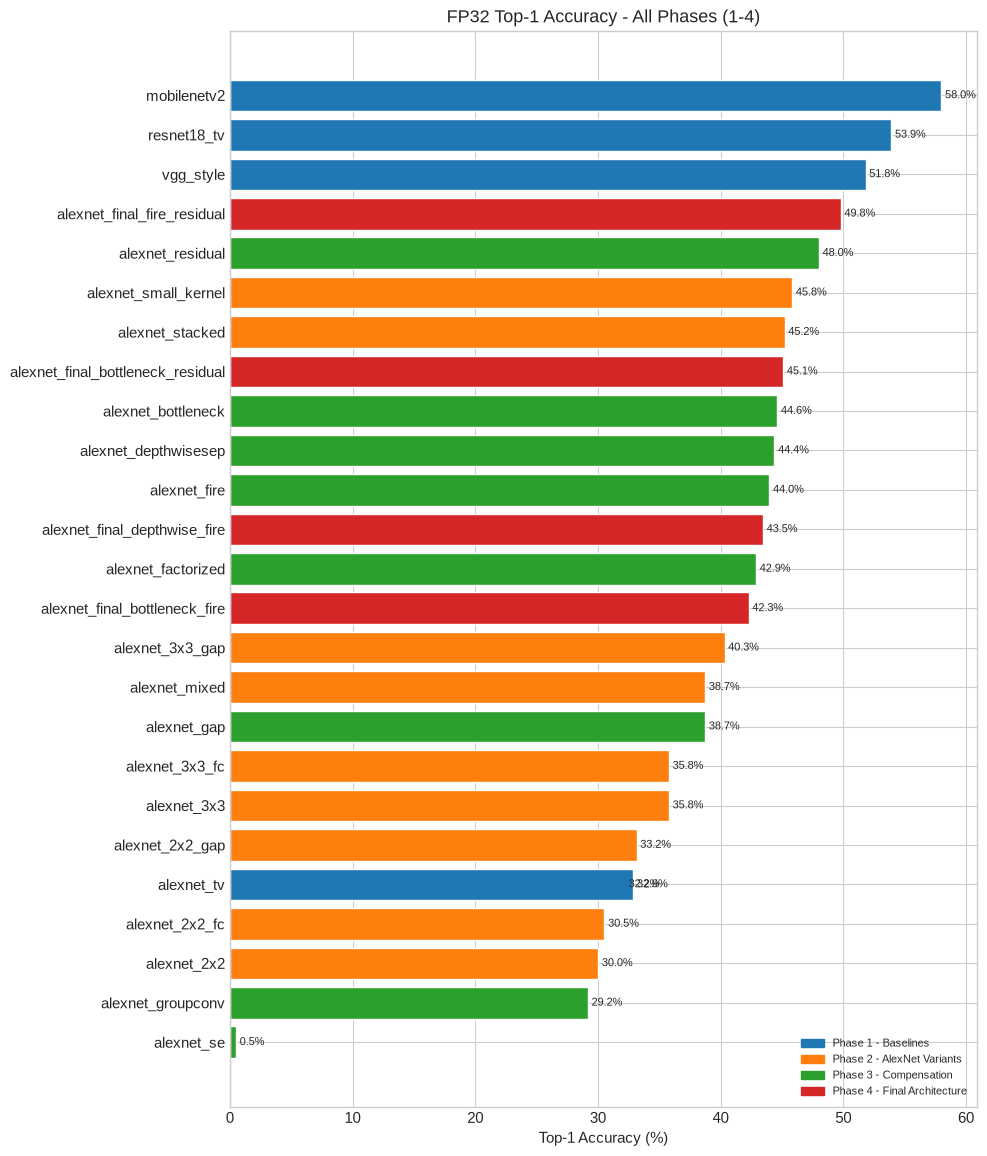

In [15]:
plot_df = fp32_rank_display.sort_values('fp32_top1')
colors = [PHASE_COLORS[p] for p in plot_df['phase']]

fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.45)))
bars = ax.barh(plot_df['model_name'], plot_df['fp32_top1'], color=colors, edgecolor='white')
for bar, val in zip(bars, plot_df['fp32_top1']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Top-1 Accuracy (%)')
ax.set_title('FP32 Top-1 Accuracy - All Phases (1-4)')
handles = [mpatches.Patch(color=PHASE_COLORS[p], label=p) for p in phases if p in plot_df['phase'].values]
ax.legend(handles=handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fp32_ranking_all_phases.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. INT8 Ranking

In [16]:
int8_rank = df_summ[df_summ['int8_top1'].notna()].sort_values('int8_top1', ascending=False).reset_index(drop=True)
cols = ['phase', 'model_name', 'int8_top1', 'int8_top5', 'int8_size_mb', 'quantization_drop_top1', 'winograd_friendly']
int8_rank_display = int8_rank[[c for c in cols if c in int8_rank.columns]]
int8_rank_display.to_csv(RESULTS_DIR / 'int8_ranking.csv', index=False)

print('RANKING BY INT8 TOP-1 ACCURACY')
for i, row in int8_rank_display.iterrows():
    print(f"{i + 1:2d}. {row['model_name']:34s} [{row['phase']:28s}] int8_top1={row['int8_top1']:6.2f}%")
int8_rank_display

RANKING BY INT8 TOP-1 ACCURACY
 1. vgg_style                          [Phase 1 - Baselines         ] int8_top1= 51.19%
 2. alexnet_final_fire_residual        [Phase 4 - Final Architecture] int8_top1= 49.20%
 3. alexnet_residual                   [Phase 3 - Compensation      ] int8_top1= 47.27%
 4. alexnet_final_bottleneck_residual  [Phase 4 - Final Architecture] int8_top1= 45.98%
 5. alexnet_bottleneck                 [Phase 3 - Compensation      ] int8_top1= 44.54%
 6. alexnet_fire                       [Phase 3 - Compensation      ] int8_top1= 44.30%
 7. alexnet_final_bottleneck_fire      [Phase 4 - Final Architecture] int8_top1= 44.00%
 8. alexnet_final_depthwise_fire       [Phase 4 - Final Architecture] int8_top1= 42.79%
 9. alexnet_factorized                 [Phase 3 - Compensation      ] int8_top1= 42.60%
10. alexnet_stacked                    [Phase 2 - AlexNet Variants  ] int8_top1= 42.31%
11. alexnet_depthwisesep               [Phase 3 - Compensation      ] int8_top1= 41.47%
1

,phase,model_name,int8_top1,int8_top5,int8_size_mb,quantization_drop_top1,winograd_friendly
0,Phase 1 - Baselines,vgg_style,51.188743,75.520074,2.376703,0.626063,True
1,Phase 4 - Final Architecture,alexnet_final_fire_residual,49.201027,74.387586,0.746309,0.592265,True
2,Phase 3 - Compensation,alexnet_residual,47.273704,72.499549,58.102711,0.739235,True
3,Phase 4 - Final Architecture,alexnet_final_bottleneck_residual,45.980674,72.328943,0.637690,-0.881073,True
4,Phase 3 - Compensation,alexnet_bottleneck,44.539082,71.014529,0.431780,0.083897,True
5,Phase 3 - Compensation,alexnet_fire,44.303995,70.881659,0.551374,-0.327522,True
6,Phase 4 - Final Architecture,alexnet_final_bottleneck_fire,44.001037,70.151949,0.545216,-1.714957,True
7,Phase 4 - Final Architecture,alexnet_final_depthwise_fire,42.789248,68.953073,0.509390,0.666627,True
8,Phase 3 - Compensation,alexnet_factorized,42.597890,67.798507,54.683115,0.292253,False
9,Phase 2 - AlexNet Variants,alexnet_stacked,42.309719,68.345517,57.941553,2.910036,True


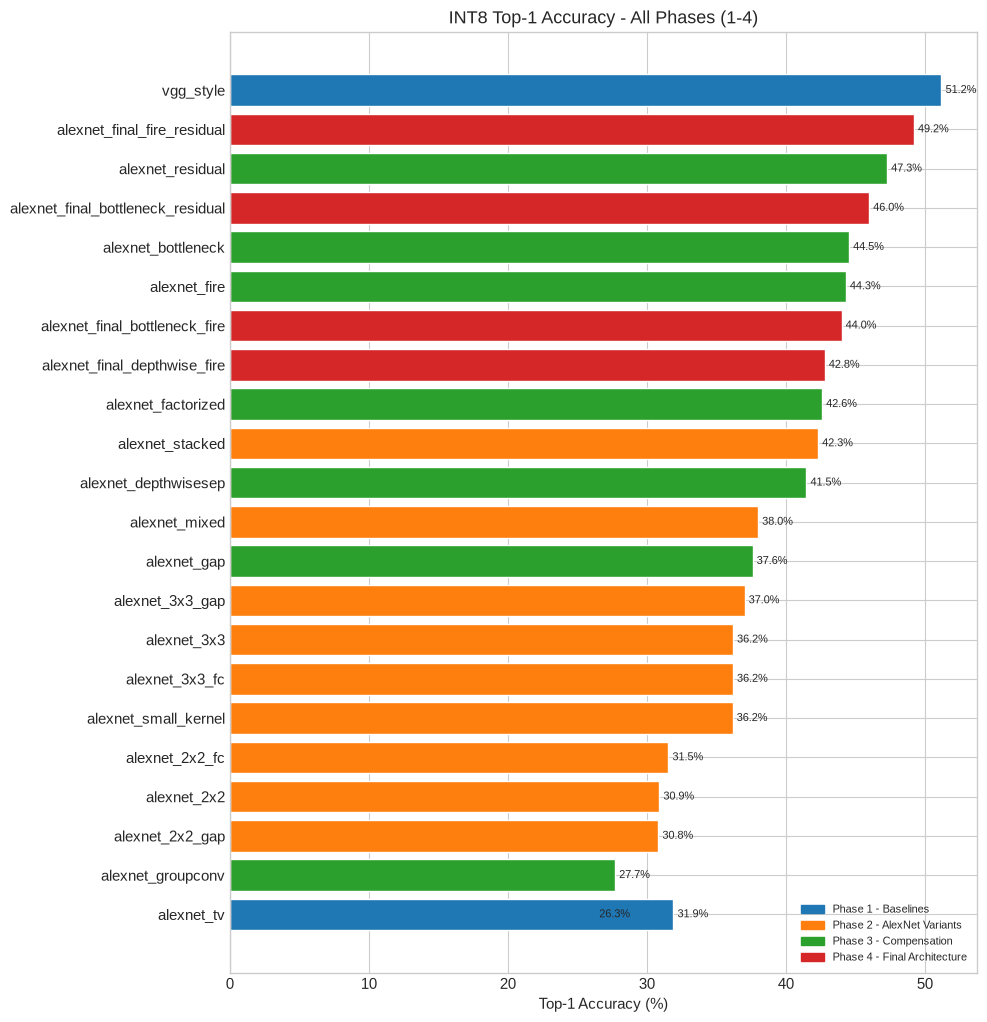

In [17]:
plot_df = int8_rank_display.sort_values('int8_top1')
colors = [PHASE_COLORS[p] for p in plot_df['phase']]

fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.45)))
bars = ax.barh(plot_df['model_name'], plot_df['int8_top1'], color=colors, edgecolor='white')
for bar, val in zip(bars, plot_df['int8_top1']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Top-1 Accuracy (%)')
ax.set_title('INT8 Top-1 Accuracy - All Phases (1-4)')
handles = [mpatches.Patch(color=PHASE_COLORS[p], label=p) for p in phases if p in plot_df['phase'].values]
ax.legend(handles=handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'int8_ranking_all_phases.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Quantization Accuracy-Drop Analysis

In [18]:
drop_rank = df_summ[df_summ['quantization_drop_top1'].notna()].sort_values('quantization_drop_top1').reset_index(drop=True)
cols = ['phase', 'model_name', 'fp32_top1', 'int8_top1', 'quantization_drop_top1', 'winograd_friendly']
drop_rank_display = drop_rank[[c for c in cols if c in drop_rank.columns]]
drop_rank_display.to_csv(RESULTS_DIR / 'quantization_drop_ranking.csv', index=False)

print('MOST QUANTIZATION-STABLE MODELS (lowest FP32->INT8 drop first; negative = gain)')
for i, row in drop_rank_display.iterrows():
    sign = '+' if row['quantization_drop_top1'] < 0 else '-'
    print(f"{i + 1:2d}. {row['model_name']:34s} [{row['phase']:28s}] drop={sign}{abs(row['quantization_drop_top1']):.2f}pp")
drop_rank_display

MOST QUANTIZATION-STABLE MODELS (lowest FP32->INT8 drop first; negative = gain)
 1. alexnet_final_bottleneck_fire      [Phase 4 - Final Architecture] drop=+1.71pp
 2. alexnet_2x2_fc                     [Phase 2 - AlexNet Variants  ] drop=+1.01pp
 3. alexnet_final_bottleneck_residual  [Phase 4 - Final Architecture] drop=+0.88pp
 4. alexnet_2x2                        [Phase 2 - AlexNet Variants  ] drop=+0.86pp
 5. alexnet_3x3                        [Phase 2 - AlexNet Variants  ] drop=+0.40pp
 6. alexnet_3x3_fc                     [Phase 2 - AlexNet Variants  ] drop=+0.40pp
 7. alexnet_fire                       [Phase 3 - Compensation      ] drop=+0.33pp
 8. alexnet_bottleneck                 [Phase 3 - Compensation      ] drop=-0.08pp
 9. alexnet_factorized                 [Phase 3 - Compensation      ] drop=-0.29pp
10. alexnet_final_fire_residual        [Phase 4 - Final Architecture] drop=-0.59pp
11. vgg_style                          [Phase 1 - Baselines         ] drop=-0.63pp
12. ale

,phase,model_name,fp32_top1,int8_top1,quantization_drop_top1,winograd_friendly
0,Phase 4 - Final Architecture,alexnet_final_bottleneck_fire,42.286080,44.001037,-1.714957,True
1,Phase 2 - AlexNet Variants,alexnet_2x2_fc,30.532345,31.539398,-1.007053,None
2,Phase 4 - Final Architecture,alexnet_final_bottleneck_residual,45.099601,45.980674,-0.881073,True
3,Phase 2 - AlexNet Variants,alexnet_2x2,30.023813,30.888581,-0.864768,False
4,Phase 2 - AlexNet Variants,alexnet_3x3,35.787162,36.190116,-0.402954,True
5,Phase 2 - AlexNet Variants,alexnet_3x3_fc,35.787162,36.185488,-0.398326,None
6,Phase 3 - Compensation,alexnet_fire,43.976474,44.303995,-0.327522,True
7,Phase 3 - Compensation,alexnet_bottleneck,44.622979,44.539082,0.083897,True
8,Phase 3 - Compensation,alexnet_factorized,42.890143,42.597890,0.292253,False
9,Phase 4 - Final Architecture,alexnet_final_fire_residual,49.793291,49.201027,0.592265,True


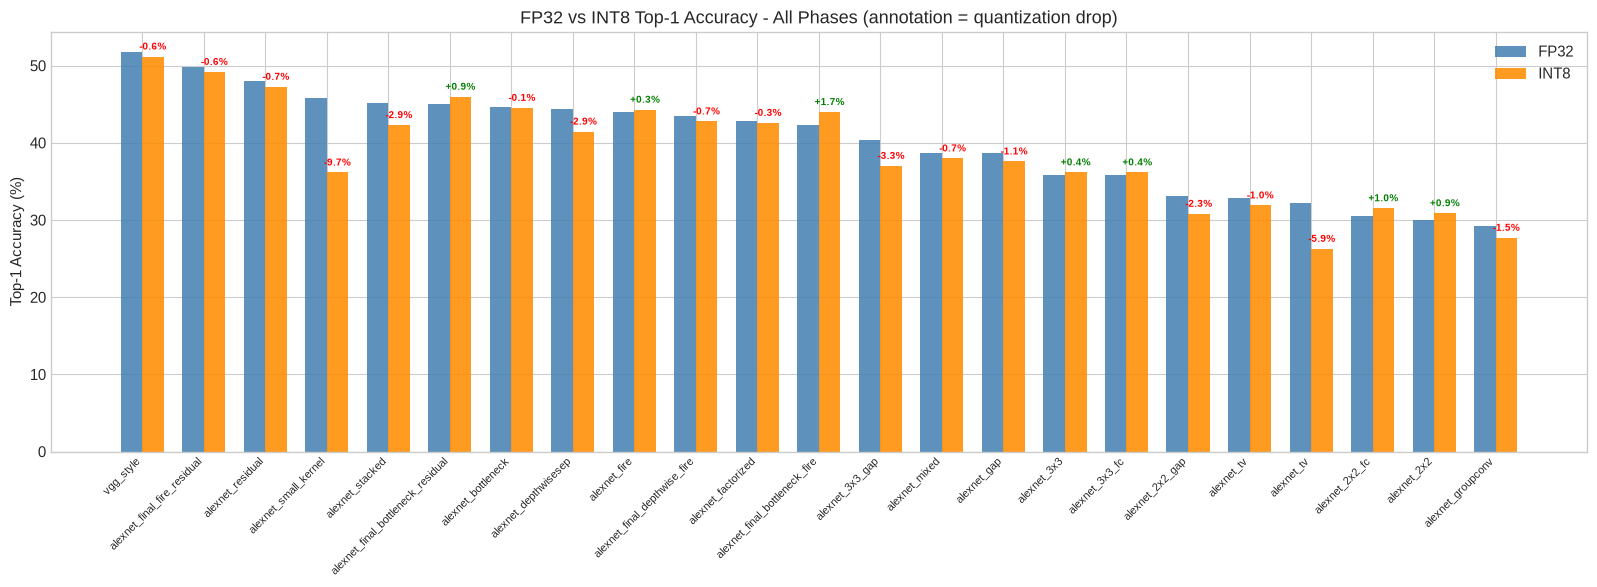

In [19]:
plot_df = drop_rank_display.sort_values('fp32_top1', ascending=False).reset_index(drop=True)
x = np.arange(len(plot_df))
w = 0.35

fig, ax = plt.subplots(figsize=(max(12, len(plot_df) * 0.7), 6))
ax.bar(x - w / 2, plot_df['fp32_top1'], w, label='FP32', color='steelblue', alpha=0.87)
ax.bar(x + w / 2, plot_df['int8_top1'], w, label='INT8', color='darkorange', alpha=0.87)

for i, row in plot_df.iterrows():
    drop = row['quantization_drop_top1']
    color = 'red' if drop > 0 else 'green'
    sign = '-' if drop > 0 else '+'
    ax.annotate(f'{sign}{abs(drop):.1f}%', xy=(x[i] + w / 2, row['int8_top1']),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=7,
                color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(plot_df['model_name'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('FP32 vs INT8 Top-1 Accuracy - All Phases (annotation = quantization drop)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'quantization_drop_all_phases.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model Size Comparison

In [20]:
size_df = df_summ[df_summ['fp32_size_mb'].notna()].copy()
size_df['accuracy_per_mb_fp32'] = size_df['fp32_top1'] / size_df['fp32_size_mb']

size_cols = ['phase', 'model_name', 'fp32_size_mb', 'int8_size_mb', 'compression_ratio',
             'param_efficiency_top1_per_m', 'accuracy_per_mb_fp32', 'winograd_friendly']
size_display = (size_df[[c for c in size_cols if c in size_df.columns]]
                 .sort_values('accuracy_per_mb_fp32', ascending=False)
                 .reset_index(drop=True))
size_display.to_csv(RESULTS_DIR / 'size_efficiency_ranking.csv', index=False)
size_display

,phase,model_name,fp32_size_mb,int8_size_mb,compression_ratio,param_efficiency_top1_per_m,accuracy_per_mb_fp32,winograd_friendly
0,Phase 3 - Compensation,alexnet_depthwisesep,3.654016,0.399755,9.140629,141.818193,12.148279,True
1,Phase 3 - Compensation,alexnet_bottleneck,4.491745,0.431780,10.402859,116.051948,9.934442,True
2,Phase 4 - Final Architecture,alexnet_final_depthwise_fire,5.511263,0.509390,10.819341,91.657349,7.884921,True
3,Phase 3 - Compensation,alexnet_fire,5.989412,0.551374,10.862695,85.381826,7.342369,True
4,Phase 4 - Final Architecture,alexnet_final_bottleneck_fire,5.882781,0.545216,10.789825,83.568980,7.188111,True
5,Phase 4 - Final Architecture,alexnet_final_bottleneck_residual,6.653960,0.637690,10.434481,78.977217,6.777859,True
6,Phase 4 - Final Architecture,alexnet_final_fire_residual,8.093657,0.746309,10.844909,71.250272,6.152138,True
7,Phase 2 - AlexNet Variants,alexnet_2x2_gap,12.063150,1.040150,11.597514,31.574628,2.748206,None
8,Phase 2 - AlexNet Variants,alexnet_small_kernel,18.353315,1.561041,11.757101,28.607518,2.497454,True
9,Phase 2 - AlexNet Variants,alexnet_2x2,12.062769,1.039989,11.598934,28.582447,2.488965,False


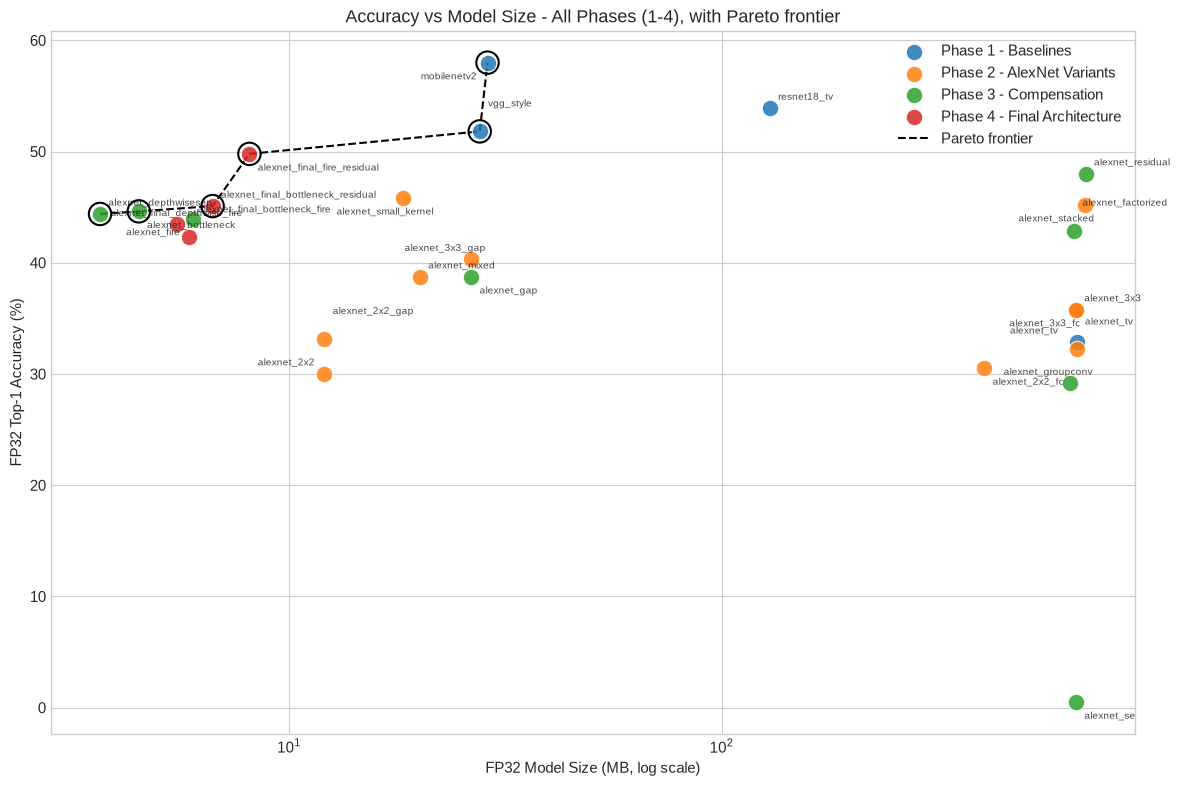

In [21]:
def pareto_frontier(df, size_col='fp32_size_mb', acc_col='fp32_top1'):
    '''Models with no smaller-or-equal model at least as accurate (max accuracy per size, ascending size).'''
    sorted_df = df.sort_values(size_col).reset_index(drop=True)
    keep = []
    best_acc = -np.inf
    for i, row in sorted_df.iterrows():
        if row[acc_col] > best_acc:
            keep.append(i)
            best_acc = row[acc_col]
    return sorted_df.loc[keep]


pareto_df = pareto_frontier(size_df)
pareto_df[['phase', 'model_name', 'fp32_size_mb', 'fp32_top1']].to_csv(
    RESULTS_DIR / 'pareto_frontier_size_accuracy.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 8))
for phase in phases:
    sub = size_df[size_df['phase'] == phase]
    if sub.empty:
        continue
    ax.scatter(sub['fp32_size_mb'], sub['fp32_top1'], c=[PHASE_COLORS[phase]], s=140,
               label=phase, alpha=0.85, edgecolors='white', lw=0.8, zorder=3)
annotate_labels(ax, size_df, 'fp32_size_mb', 'fp32_top1', 'model_name')

ax.plot(pareto_df['fp32_size_mb'], pareto_df['fp32_top1'], color='black', linestyle='--',
        lw=1.5, zorder=2, label='Pareto frontier')
ax.scatter(pareto_df['fp32_size_mb'], pareto_df['fp32_top1'], facecolors='none',
           edgecolors='black', s=260, lw=1.5, zorder=4)

ax.set_xscale('log')
ax.set_xlabel('FP32 Model Size (MB, log scale)')
ax.set_ylabel('FP32 Top-1 Accuracy (%)')
ax.set_title('Accuracy vs Model Size - All Phases (1-4), with Pareto frontier')
ax.legend(loc='best')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'accuracy_vs_size_all_phases.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Training Time Comparison

In [22]:
def load_training_times(phase_dirs):
    '''Per-model FP32/QAT epoch count, avg epoch time, and total time from each phase's experiment_summary.json.'''
    rows = []
    for label, d in phase_dirs.items():
        f = d / 'experiment_summary.json'
        if not f.exists():
            continue
        with open(f) as fp:
            data = json.load(fp)
        fp32_results = data.get('fp32_training_results', {})
        qat_results = data.get('qat_training_results', {})
        for model, fp32 in fp32_results.items():
            qat = qat_results.get(model, {})
            fp32_epochs = len(fp32.get('history', {}).get('epoch_time_s', []))
            qat_epochs = len(qat.get('history', {}).get('epoch_time_s', []))
            fp32_total = fp32.get('total_training_time_s', np.nan)
            qat_total = qat.get('total_training_time_s', np.nan)
            rows.append({
                'phase': label,
                'model_name': model,
                'fp32_epochs': fp32_epochs,
                'fp32_avg_epoch_time_s': fp32_total / fp32_epochs if fp32_epochs else np.nan,
                'fp32_total_time_s': fp32_total,
                'qat_epochs': qat_epochs,
                'qat_avg_epoch_time_s': qat_total / qat_epochs if qat_epochs else np.nan,
                'qat_total_time_s': qat_total,
                'total_time_s': fp32_total + (qat_total if not np.isnan(qat_total) else 0.0),
            })
    return pd.DataFrame(rows) if rows else pd.DataFrame()


df_time = load_training_times(PHASE_DIRS)
time_rank = df_time.sort_values('total_time_s', ascending=False).reset_index(drop=True)
time_rank.to_csv(RESULTS_DIR / 'training_time_comparison.csv', index=False)

print('TOTAL TRAINING TIME (FP32 + QAT), longest first')
for i, row in time_rank.iterrows():
    print(f"{i + 1:2d}. {row['model_name']:34s} [{row['phase']:28s}] "
          f"total={row['total_time_s'] / 60:7.1f} min  "
          f"(fp32 avg/epoch={row['fp32_avg_epoch_time_s']:.1f}s, qat avg/epoch={row['qat_avg_epoch_time_s']:.1f}s)")
time_rank

TOTAL TRAINING TIME (FP32 + QAT), longest first
 1. alexnet_tv                         [Phase 1 - Baselines         ] total=   76.6 min  (fp32 avg/epoch=49.1s, qat avg/epoch=52.3s)
 2. alexnet_tv                         [Phase 2 - AlexNet Variants  ] total=   45.6 min  (fp32 avg/epoch=37.5s, qat avg/epoch=0.0s)
 3. vgg_style                          [Phase 1 - Baselines         ] total=   42.0 min  (fp32 avg/epoch=29.6s, qat avg/epoch=42.6s)
 4. alexnet_fire                       [Phase 3 - Compensation      ] total=   40.1 min  (fp32 avg/epoch=31.8s, qat avg/epoch=65.2s)
 5. alexnet_residual                   [Phase 3 - Compensation      ] total=   39.8 min  (fp32 avg/epoch=9.4s, qat avg/epoch=97.3s)
 6. alexnet_final_fire_residual        [Phase 4 - Final Architecture] total=   32.5 min  (fp32 avg/epoch=22.5s, qat avg/epoch=24.4s)
 7. alexnet_final_depthwise_fire       [Phase 4 - Final Architecture] total=   30.6 min  (fp32 avg/epoch=21.6s, qat avg/epoch=21.7s)
 8. alexnet_stacked    

,phase,model_name,fp32_epochs,fp32_avg_epoch_time_s,fp32_total_time_s,qat_epochs,qat_avg_epoch_time_s,qat_total_time_s,total_time_s
0,Phase 1 - Baselines,alexnet_tv,85,49.135404,4176.509352,8,5.231116e+01,418.489318,4594.998670
1,Phase 2 - AlexNet Variants,alexnet_tv,73,37.459401,2734.536307,20,1.907349e-07,0.000004,2734.536311
2,Phase 1 - Baselines,vgg_style,68,29.553125,2009.612514,12,4.258495e+01,511.019410,2520.631924
3,Phase 3 - Compensation,alexnet_fire,47,31.790245,1494.141500,14,6.521478e+01,913.006935,2407.148435
4,Phase 3 - Compensation,alexnet_residual,68,9.390220,638.534984,18,9.725602e+01,1750.608385,2389.143369
5,Phase 4 - Final Architecture,alexnet_final_fire_residual,77,22.456021,1729.113626,9,2.438117e+01,219.430523,1948.544149
6,Phase 4 - Final Architecture,alexnet_final_depthwise_fire,76,21.587517,1640.651290,9,2.174311e+01,195.687946,1836.339236
7,Phase 2 - AlexNet Variants,alexnet_stacked,98,9.147269,896.432341,19,4.478940e+01,850.998517,1747.430858
8,Phase 4 - Final Architecture,alexnet_final_bottleneck_residual,38,24.589653,934.406803,15,3.748066e+01,562.209836,1496.616639
9,Phase 2 - AlexNet Variants,alexnet_2x2_fc,34,31.222211,1061.555181,10,3.764872e+01,376.487225,1438.042406


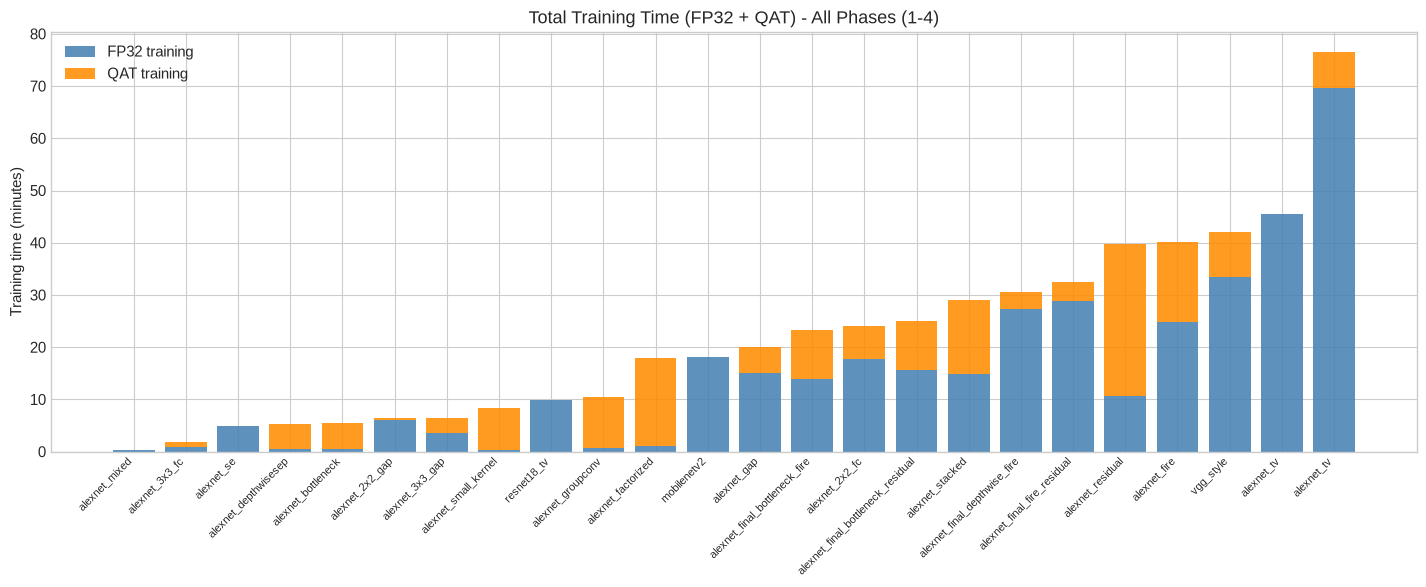

In [23]:
plot_df = time_rank.sort_values('total_time_s')
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(max(12, len(plot_df) * 0.6), 6))
ax.bar(x, plot_df['fp32_total_time_s'] / 60, label='FP32 training', color='steelblue', alpha=0.87)
ax.bar(x, plot_df['qat_total_time_s'].fillna(0) / 60, bottom=plot_df['fp32_total_time_s'] / 60,
       label='QAT training', color='darkorange', alpha=0.87)

ax.set_xticks(x)
ax.set_xticklabels(plot_df['model_name'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Training time (minutes)')
ax.set_title('Total Training Time (FP32 + QAT) - All Phases (1-4)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'training_time_all_phases.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Latency Comparison

> **Caveat:** FP32 is benchmarked on GPU, INT8 on CPU (the `fbgemm` quantization backend used in this project is CPU-only, per `CLAUDE.md`). This is a deployment-target comparison, not a same-hardware speedup number.

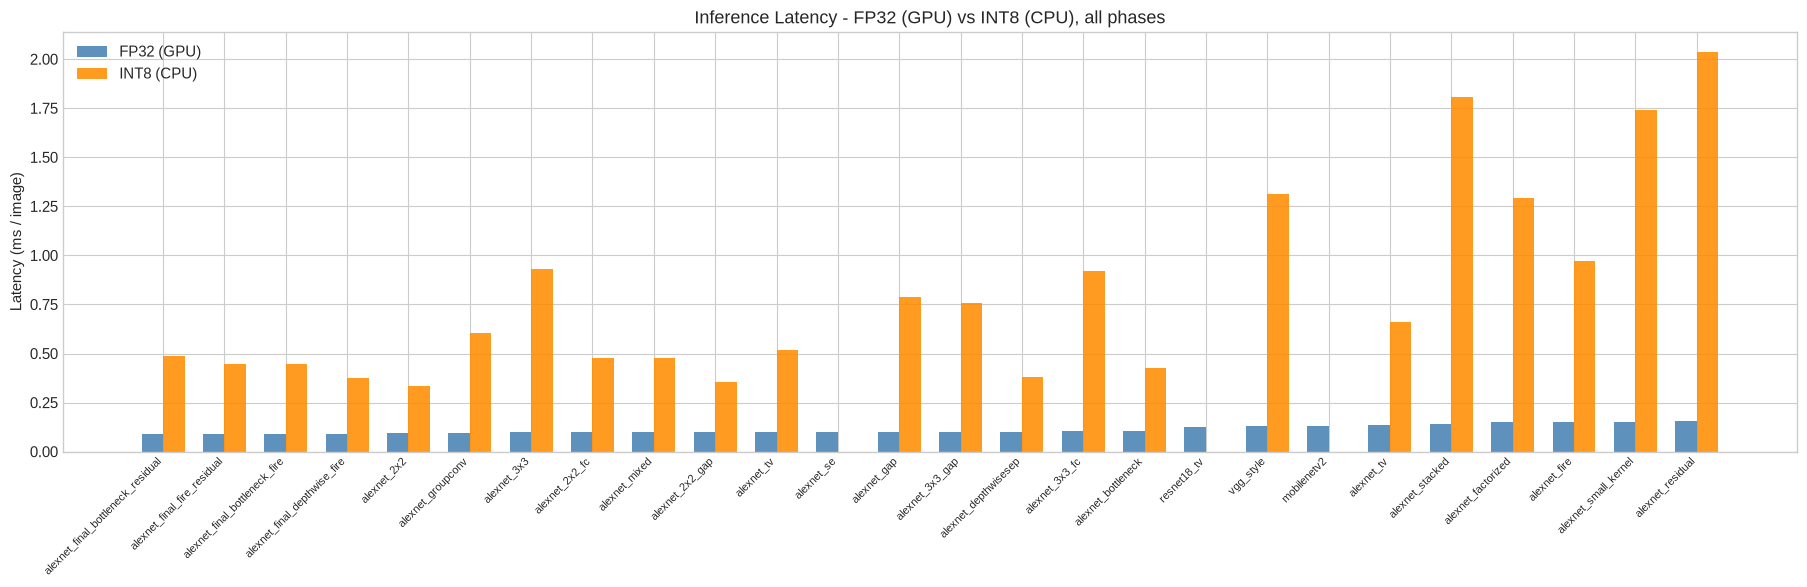

In [24]:
lat_df = df_summ[df_summ['fp32_latency_ms_per_image'].notna()].sort_values('fp32_latency_ms_per_image').reset_index(drop=True)

if lat_df.empty:
    print('[skip] No latency data available')
else:
    x = np.arange(len(lat_df))
    w = 0.35

    fig, ax = plt.subplots(figsize=(max(12, len(lat_df) * 0.7), 6))
    ax.bar(x - w / 2, lat_df['fp32_latency_ms_per_image'], w, label='FP32 (GPU)', color='steelblue', alpha=0.87)
    has_int8_lat = lat_df['int8_latency_ms_per_image'].notna()
    ax.bar(x[has_int8_lat] + w / 2, lat_df.loc[has_int8_lat, 'int8_latency_ms_per_image'], w,
           label='INT8 (CPU)', color='darkorange', alpha=0.87)

    ax.set_xticks(x)
    ax.set_xticklabels(lat_df['model_name'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Latency (ms / image)')
    ax.set_title('Inference Latency - FP32 (GPU) vs INT8 (CPU), all phases')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'latency_comparison_all_phases.png', dpi=150, bbox_inches='tight')
    plt.show()

    lat_cols = ['phase', 'model_name', 'fp32_latency_ms_per_image', 'int8_latency_ms_per_image',
                'fp32_throughput_img_per_s', 'int8_throughput_img_per_s']
    lat_display = lat_df[[c for c in lat_cols if c in lat_df.columns]]
    lat_display.to_csv(RESULTS_DIR / 'latency_comparison.csv', index=False)
    lat_display

## 7. Winograd Compatibility Discussion

In [25]:
wino_df = df_summ[df_summ['winograd_friendly'].notna()].copy()
wino_summary = wino_df.groupby('winograd_friendly').agg(
    n=('model_name', 'count'),
    mean_fp32_top1=('fp32_top1', 'mean'),
    mean_quant_drop=('quantization_drop_top1', 'mean'),
    mean_acc_per_mb=('param_efficiency_top1_per_m', 'mean'),
).reset_index()
wino_summary['winograd_friendly'] = wino_summary['winograd_friendly'].map(
    {True: 'Winograd-friendly', False: 'Not Winograd-friendly'})
wino_summary.to_csv(RESULTS_DIR / 'winograd_group_summary.csv', index=False)
wino_summary

,winograd_friendly,n,mean_fp32_top1,mean_quant_drop,mean_acc_per_mb
0,Not Winograd-friendly,7,41.236263,1.416966,11.539813
1,Winograd-friendly,15,40.581071,1.249993,49.229144


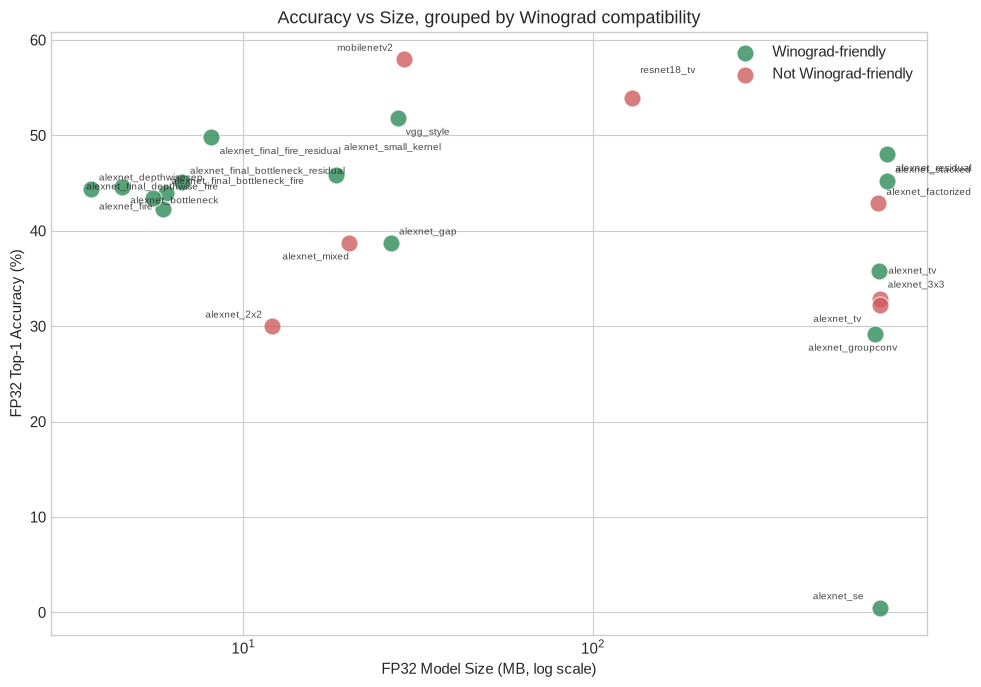

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))
for friendly, color, label in [(True, 'seagreen', 'Winograd-friendly'), (False, 'indianred', 'Not Winograd-friendly')]:
    sub = wino_df[wino_df['winograd_friendly'] == friendly]
    if sub.empty:
        continue
    ax.scatter(sub['fp32_size_mb'], sub['fp32_top1'], c=color, s=150, alpha=0.8,
               label=label, edgecolors='white', lw=0.8, zorder=3)
annotate_labels(ax, wino_df, 'fp32_size_mb', 'fp32_top1', 'model_name')

ax.set_xscale('log')
ax.set_xlabel('FP32 Model Size (MB, log scale)')
ax.set_ylabel('FP32 Top-1 Accuracy (%)')
ax.set_title('Accuracy vs Size, grouped by Winograd compatibility')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'winograd_compatibility_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the group-summary table and scatter plot above:** every Phase 3 compensation mechanism and all four Phase 4 hybrids are built on uniform 3x3 (or 1x1 + 3x3 bottleneck/Fire-style) convolutions, so they are Winograd-friendly by construction. The non-Winograd-friendly outliers are `alexnet_2x2` (even 2x2 kernels), `alexnet_mixed` (partial 2x2), `alexnet_factorized` (asymmetric 1x3/3x1 kernels), and the pretrained baselines (`alexnet_tv`, `resnet18_tv`, `mobilenetv2` — large or non-standard stem kernels).

If the Winograd-friendly group's mean FP32 accuracy and mean accuracy-per-MB are not clearly worse than the non-friendly group's (check the table above after running this notebook), that supports this study's core hypothesis: **restricting kernels to Winograd-compatible sizes costs little to no accuracy once paired with the right compensation mechanism (Bottleneck, Fire, or Residual)** — the accuracy penalty comes from *naive* kernel restriction (plain `AlexNet3x3`/`AlexNet2x2`), not from the kernel-size constraint itself.

## 8. Extreme Compression Appendix (Phase 4.1)

Reference only — figures for this data already exist in `results/figures/` (`compression_methods_breakdown.png`, `compression_phase4_1_impact.png`, `compression_phase4_1_accuracy_vs_size.png`), produced by `compression_phase4_1.ipynb` / `final_architecture_results.ipynb`.

In [27]:
comp_by_method_path = COMPRESSION_DIR / 'compression_by_method.csv'
comp_pareto_path = COMPRESSION_DIR / 'pareto_frontier.csv'

if comp_by_method_path.exists():
    comp_by_method = pd.read_csv(comp_by_method_path)
    comp_by_method.to_csv(RESULTS_DIR / 'compression_by_method.csv', index=False)
    print('Mean results by compression method:')
    display(comp_by_method)
else:
    print('[skip] No compression_by_method.csv found')

if comp_pareto_path.exists():
    comp_pareto = pd.read_csv(comp_pareto_path)
    comp_pareto.to_csv(RESULTS_DIR / 'compression_pareto_frontier.csv', index=False)
    print('Pareto-optimal model x method combinations:')
    display(comp_pareto)
else:
    print('[skip] No pareto_frontier.csv found')

Mean results by compression method:


,method,mean_top1,mean_drop_pp,mean_ratio,mean_acc_per_mb,n
0,binary_qat,10.728811,37.426856,29.701204,164.847061,5
1,int2_qat,17.404999,30.750668,15.420149,145.439953,5
2,int4_ptq,25.310649,22.845018,7.861742,106.214611,5
3,int4_qat,43.305823,1.023998,7.864515,230.174613,3
4,int8,47.399935,0.755733,3.970045,90.759172,5
5,mixed,44.524813,-0.194992,7.051900,215.314776,3
6,ternary_qat,26.055524,22.100143,15.420149,205.409831,5


Pareto-optimal model x method combinations:


,model,method,precision,fp32_baseline_acc,compressed_top1_acc,acc_drop_pp,compression_ratio,compressed_size_mb,latency_ms,acc_per_mb,notes
0,mobilenetv2,int8,int8,57.995582,55.413032,2.582550,3.958495,2.365181,0.318327,23.428665,fake-quant W8/A8 PTQ
1,alexnet_final_fire_residual,int8,int8,49.793291,49.757361,0.035930,3.979767,0.666298,0.198092,74.677348,fake-quant W8/A8 PTQ
2,alexnet_fire,mixed,int4/8,43.976474,44.696173,-0.719699,6.706719,0.292267,0.331698,152.929331,per-layer INT4/INT8 (5 hi / 11 lo)
3,alexnet_bottleneck,mixed,int4/8,44.622979,44.609120,0.013858,6.946494,0.209892,0.300873,212.533410,per-layer INT4/INT8 (5 hi / 11 lo)
4,alexnet_bottleneck,int4_qat,int4,44.622979,44.337183,0.285795,7.866022,0.185356,0.190940,239.199970,"fake-quant W4/A8 QAT, per-channel"
5,alexnet_depthwisesep,mixed,int4/8,44.390011,44.269145,0.120866,7.502488,0.157833,0.094335,280.481588,per-layer INT4/INT8 (3 hi / 8 lo)
6,alexnet_depthwisesep,int4_qat,int4,44.390011,41.324723,3.065288,7.810570,0.151607,0.123792,272.577868,"fake-quant W4/A8 QAT, per-channel"
7,alexnet_final_fire_residual,ternary_qat,ternary,49.793291,36.537331,13.255960,15.603367,0.169945,0.090011,214.995335,"weight-only TWN QAT (STE), per-channel, A=FP32"
8,alexnet_fire,ternary_qat,ternary,43.976474,32.809520,11.166954,15.648263,0.125263,0.157997,261.924620,"weight-only TWN QAT (STE), per-channel, A=FP32"
9,alexnet_bottleneck,ternary_qat,ternary,44.622979,31.351751,13.271227,15.436591,0.094452,0.118686,331.933499,"weight-only TWN QAT (STE), per-channel, A=FP32"


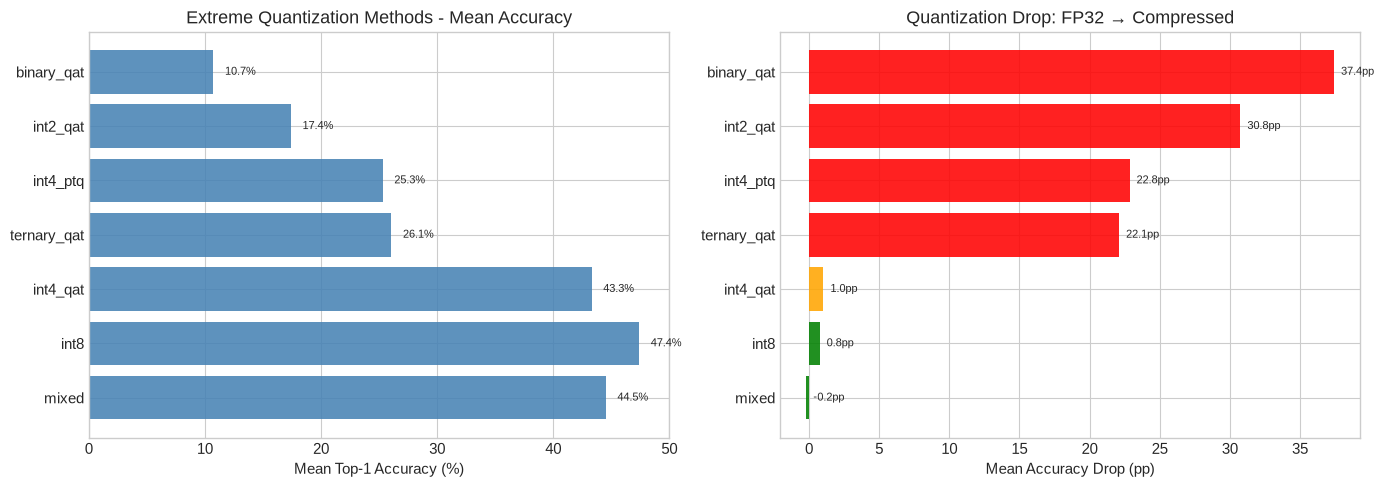

In [28]:
if not comp_by_method.empty:
    # Mean accuracy drop by method (lower is better)
    plot_df = comp_by_method.sort_values('mean_drop_pp', ascending=True)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: mean top-1 accuracy
    ax1.barh(plot_df['method'], plot_df['mean_top1'], color='steelblue', alpha=0.87)
    for i, v in enumerate(plot_df['mean_top1']):
        ax1.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)
    ax1.set_xlabel('Mean Top-1 Accuracy (%)')
    ax1.set_title('Extreme Quantization Methods - Mean Accuracy')
    ax1.set_xlim(0, 50)
    
    # Right: quantization drop
    colors = ['green' if x < 1 else 'orange' if x < 5 else 'red' for x in plot_df['mean_drop_pp']]
    ax2.barh(plot_df['method'], plot_df['mean_drop_pp'], color=colors, alpha=0.87)
    for i, v in enumerate(plot_df['mean_drop_pp']):
        ax2.text(v + 0.5, i, f'{v:.1f}pp', va='center', fontsize=8)
    ax2.set_xlabel('Mean Accuracy Drop (pp)')
    ax2.set_title('Quantization Drop: FP32 → Compressed')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'compression_methods_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

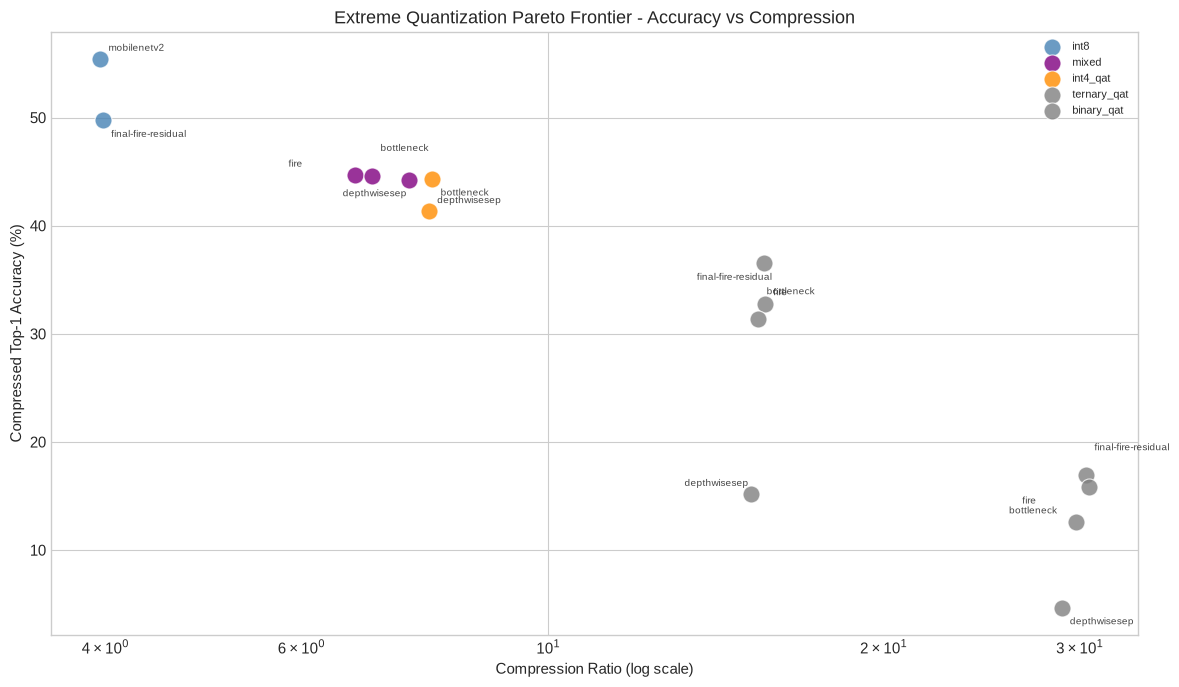

In [29]:
if not comp_pareto.empty:
    # Pareto frontier: accuracy vs compression ratio for extreme quantization
    fig, ax = plt.subplots(figsize=(12, 7))
    
    method_colors = {
        'int8': 'steelblue',
        'int4_qat': 'darkorange',
        'int4_ptq': 'coral',
        'mixed': 'purple',
        'ternary_ptq': 'red',
        'binary_ptq': 'darkred',
        'int2_ptq': 'brown',
    }
    
    for method in comp_pareto['method'].unique():
        sub = comp_pareto[comp_pareto['method'] == method]
        color = method_colors.get(method, 'gray')
        ax.scatter(sub['compression_ratio'], sub['compressed_top1_acc'], 
                  s=150, alpha=0.8, label=method, color=color, edgecolors='white', lw=0.8)
    
    annot_df = comp_pareto.copy()
    annot_df['short_name'] = annot_df['model'].str.replace('alexnet_', '', regex=False).str.replace('_', '-', regex=False).str[:20]
    annotate_labels(ax, annot_df, 'compression_ratio', 'compressed_top1_acc', 'short_name')
    
    ax.set_xscale('log')
    ax.set_xlabel('Compression Ratio (log scale)')
    ax.set_ylabel('Compressed Top-1 Accuracy (%)')
    ax.set_title('Extreme Quantization Pareto Frontier - Accuracy vs Compression')
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'compression_pareto_extreme.png', dpi=150, bbox_inches='tight')
    plt.show()

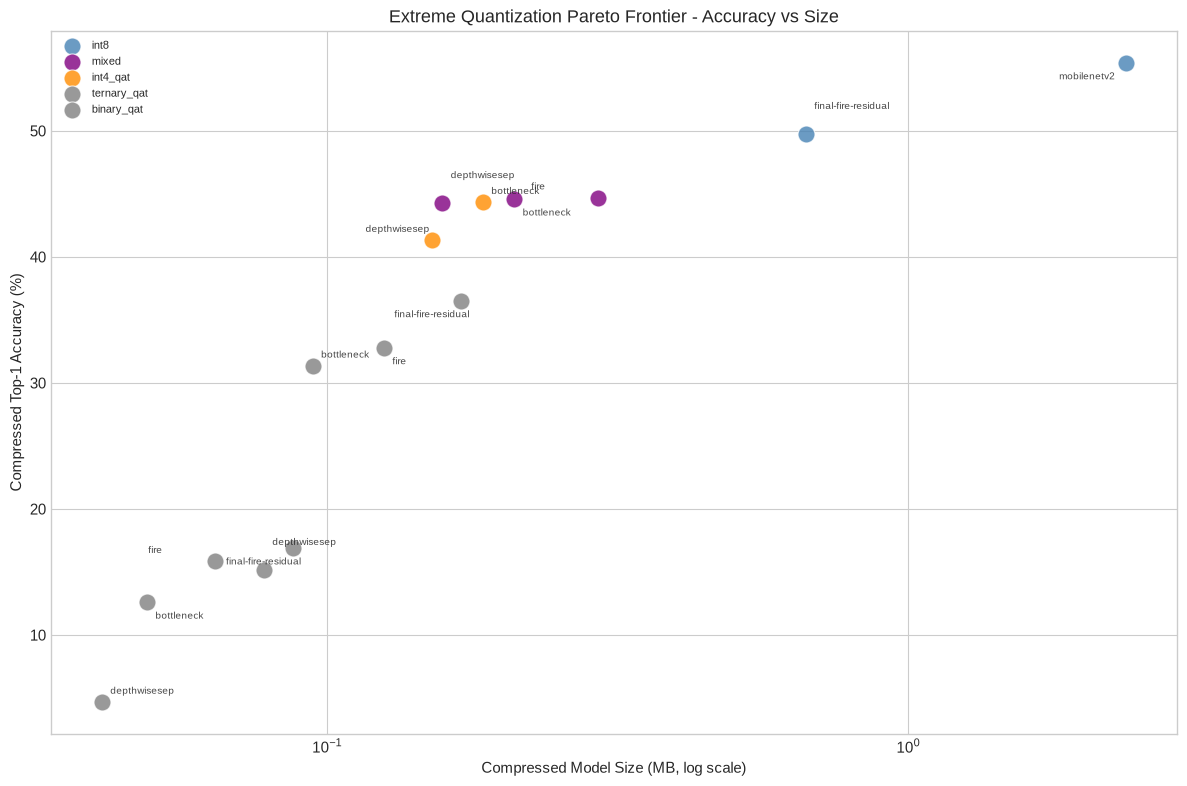

In [30]:
if not comp_pareto.empty:
    # Accuracy vs compressed model size for extreme quantization Pareto frontier
    fig, ax = plt.subplots(figsize=(12, 8))
    
    method_colors = {
        'int8': 'steelblue',
        'int4_qat': 'darkorange',
        'int4_ptq': 'coral',
        'mixed': 'purple',
        'ternary_ptq': 'red',
        'binary_ptq': 'darkred',
        'int2_ptq': 'brown',
    }
    
    for method in comp_pareto['method'].unique():
        sub = comp_pareto[comp_pareto['method'] == method]
        color = method_colors.get(method, 'gray')
        ax.scatter(sub['compressed_size_mb'], sub['compressed_top1_acc'],
                  s=150, alpha=0.8, label=method, color=color, edgecolors='white', lw=0.8)
    
    annot_df = comp_pareto.copy()
    annot_df['short_name'] = annot_df['model'].str.replace('alexnet_', '', regex=False).str.replace('_', '-', regex=False).str[:20]
    annotate_labels(ax, annot_df, 'compressed_size_mb', 'compressed_top1_acc', 'short_name')
    
    ax.set_xscale('log')
    ax.set_xlabel('Compressed Model Size (MB, log scale)')
    ax.set_ylabel('Compressed Top-1 Accuracy (%)')
    ax.set_title('Extreme Quantization Pareto Frontier - Accuracy vs Size')
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'compression_accuracy_vs_size.png', dpi=150, bbox_inches='tight')
    plt.show()

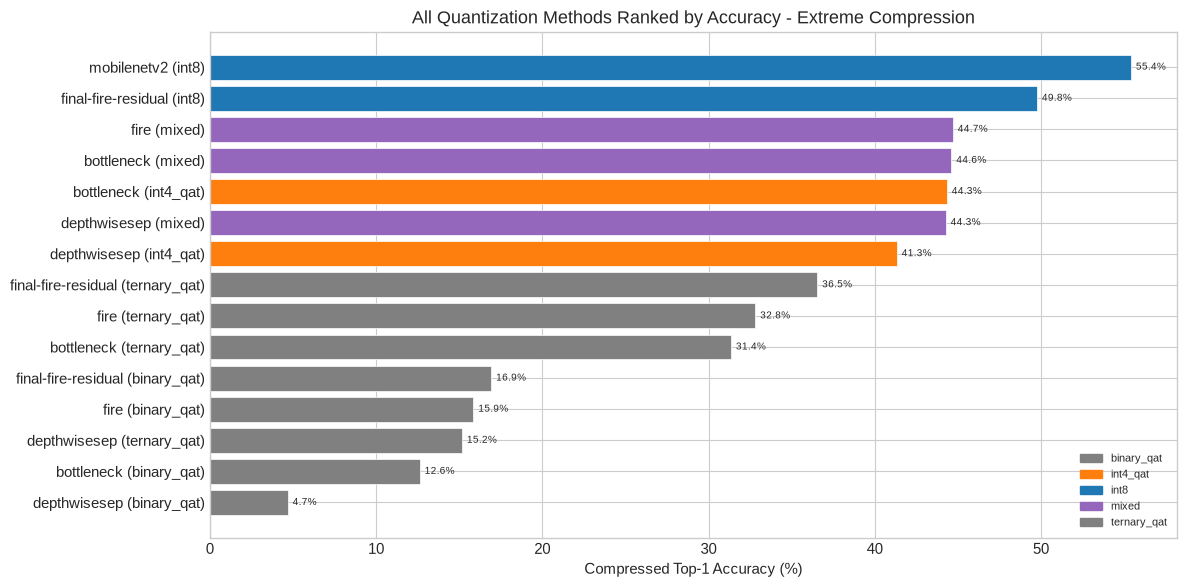

In [31]:
if not comp_pareto.empty:
    # All quantization methods ranked by accuracy (extreme quantization)
    plot_df = comp_pareto.sort_values('compressed_top1_acc', ascending=True).reset_index(drop=True)
    
    method_colors = {
        'int8': '#1f77b4',           # steelblue (baseline)
        'int4_qat': '#ff7f0e',       # darkorange
        'int4_ptq': '#ffbb78',       # coral
        'mixed': '#9467bd',          # purple
        'ternary_ptq': '#d62728',    # red
        'binary_ptq': '#8b0000',     # darkred
        'int2_ptq': '#8b4513',       # brown
    }
    
    colors = [method_colors.get(m, 'gray') for m in plot_df['method']]
    
    fig, ax = plt.subplots(figsize=(12, max(6, len(plot_df) * 0.35)))
    bars = ax.barh(plot_df['model'].str.replace('alexnet_', '').str.replace('_', '-') + ' (' + plot_df['method'] + ')',
                   plot_df['compressed_top1_acc'], color=colors, edgecolor='white', lw=0.5)
    
    for bar, val in zip(bars, plot_df['compressed_top1_acc']):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=7)
    
    ax.set_xlabel('Compressed Top-1 Accuracy (%)')
    ax.set_title('All Quantization Methods Ranked by Accuracy - Extreme Compression')
    handles = [mpatches.Patch(color=method_colors.get(m, 'gray'), label=m) 
              for m in sorted(comp_pareto['method'].unique())]
    ax.legend(handles=handles, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'all_quantization_methods_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

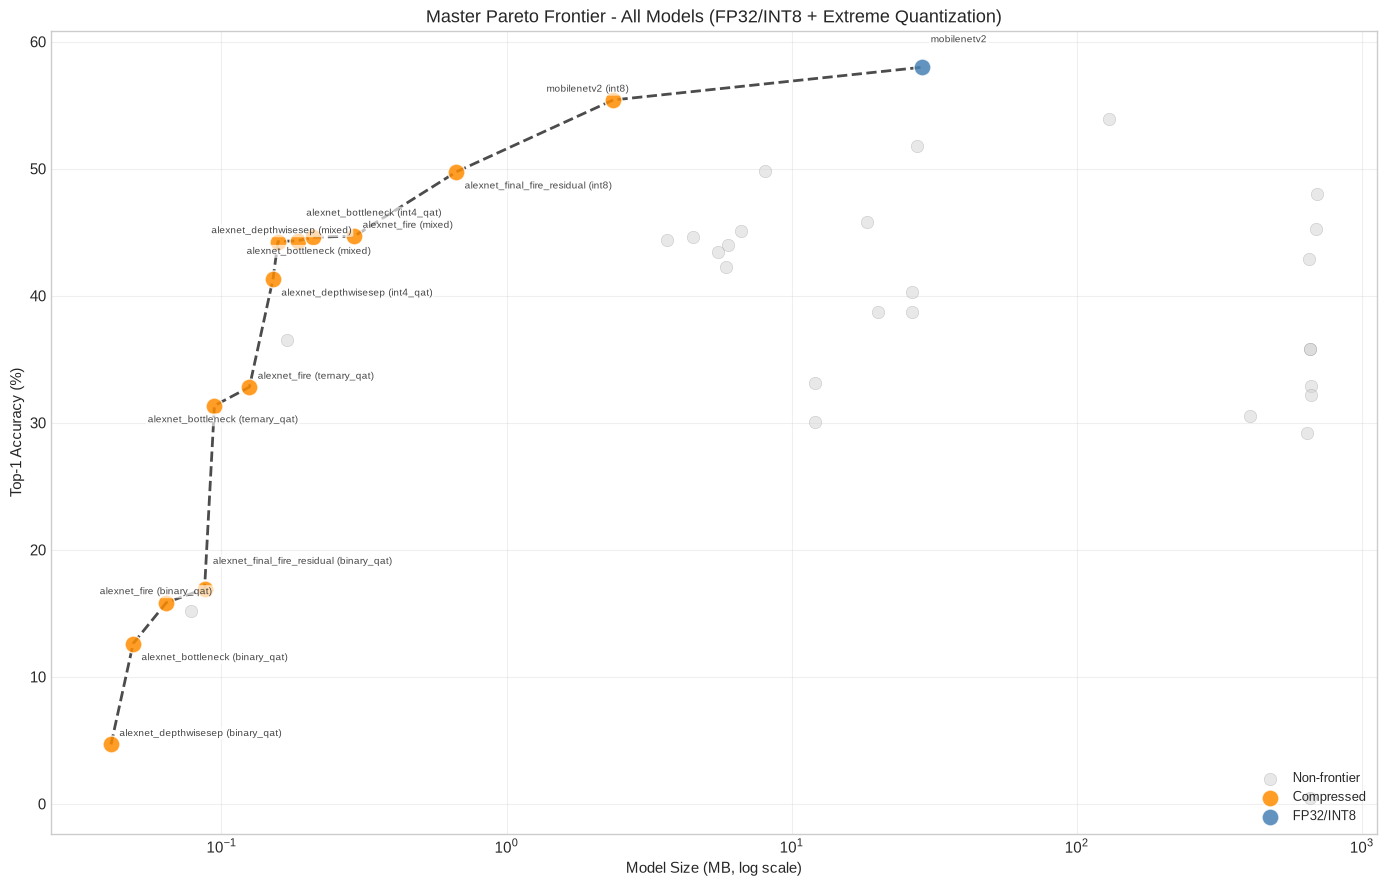

Pareto frontier: 14 models out of 41 total


In [32]:
# Master Pareto: all models (FP32 + INT8 main phases + all extreme quantization)
if not comp_pareto.empty:
    # Combine main-phase models with compression Pareto models
    main_models = size_df[['model_name', 'fp32_size_mb', 'fp32_top1']].copy()
    main_models.columns = ['name', 'size_mb', 'accuracy']
    main_models['type'] = 'FP32/INT8'
    
    comp_models = comp_pareto[['model', 'method', 'compressed_size_mb', 'compressed_top1_acc']].copy()
    comp_models.columns = ['name', 'method', 'size_mb', 'accuracy']
    comp_models['name'] = comp_models['name'] + ' (' + comp_models['method'] + ')'
    comp_models['type'] = 'Compressed'
    comp_models = comp_models[['name', 'size_mb', 'accuracy', 'type']]
    
    combined = pd.concat([main_models, comp_models], ignore_index=True)
    combined = combined.dropna(subset=['size_mb', 'accuracy'])
    
    # Compute Pareto frontier (max accuracy for a given size or smaller), all on the
    # same sorted, index-reset frame so the boolean mask and the frame line up.
    sorted_combined = combined.sort_values('size_mb').reset_index(drop=True)
    is_pareto = pd.Series(False, index=sorted_combined.index)
    best_acc = -np.inf
    for i, row in sorted_combined.iterrows():
        if row['accuracy'] > best_acc:
            is_pareto[i] = True
            best_acc = row['accuracy']
    
    pareto_points = sorted_combined[is_pareto]
    non_pareto = sorted_combined[~is_pareto]
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 9))
    
    # Plot all non-Pareto points (light gray, no labels)
    ax.scatter(non_pareto['size_mb'], non_pareto['accuracy'], 
              c='lightgray', s=80, alpha=0.5, edgecolors='gray', lw=0.3, zorder=2, label='Non-frontier')
    
    # Plot Pareto points (colored by type)
    for ptype in pareto_points['type'].unique():
        sub = pareto_points[pareto_points['type'] == ptype]
        color = 'steelblue' if ptype == 'FP32/INT8' else 'darkorange'
        ax.scatter(sub['size_mb'], sub['accuracy'], c=color, s=150, alpha=0.85, 
                  edgecolors='white', lw=1, zorder=3, label=ptype)
    
    # Draw Pareto frontier line (already sorted by size_mb)
    ax.plot(pareto_points['size_mb'], pareto_points['accuracy'], 
           color='black', linestyle='--', lw=2, zorder=2, alpha=0.7)
    
    # Annotate only Pareto frontier models
    annotate_labels(ax, pareto_points, 'size_mb', 'accuracy', 'name', boxed=True)
    
    ax.set_xscale('log')
    ax.set_xlabel('Model Size (MB, log scale)')
    ax.set_ylabel('Top-1 Accuracy (%)')
    ax.set_title('Master Pareto Frontier - All Models (FP32/INT8 + Extreme Quantization)')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'master_pareto_frontier_all_models.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    pareto_points[['name', 'size_mb', 'accuracy', 'type']].to_csv(
        RESULTS_DIR / 'master_pareto_frontier.csv', index=False)
    print(f'Pareto frontier: {len(pareto_points)} models out of {len(combined)} total')

## 9. Final Conclusions & Recommendations

This section updates and extends `ideas/BEST_MODELS.md` (Phase 1-3 only) with Phase 4 results.

**Overall winner.** `MobileNetV2` (pretrained, Phase 1) remains the best model overall by raw accuracy - 57.99% FP32 Top-1 at 2.48M params / 28.75MB. No from-scratch AlexNet-family variant across Phases 2-4 closes that gap; the pretrained-weights advantage dominates.

**Best AlexNet-family / from-scratch result.** `AlexNetFinalFireResidual` (Phase 4) is the strongest AlexNet-family model produced by this study: **49.79% FP32 Top-1 at 8.09MB** - beating Phase 3's `AlexNetResidual` (48.01% at 694MB) at roughly 85x smaller size. This confirms that combining Fire's squeeze-expand compression with residual skip connections is the most effective architectural combination found across all four phases.

**Best efficiency (accuracy per MB).** `AlexNetDepthwiseSep` (Phase 3) remains the most size-efficient model overall - 44.39% FP32 Top-1 at 3.65MB (12.15 Acc/MB) - though its QAT drop (-2.92pp) makes it less attractive than the Bottleneck/Fire family for INT8 deployment.

**Best quantization-stable tiny models.** `AlexNetBottleneck` (44.62% FP32, -0.08pp INT8 drop) and `AlexNetFire` (43.98% FP32, +0.33pp INT8 gain) remain Pareto-optimal for INT8 deployment - both under 6MB with essentially zero (or negative) quantization drop. Check the INT8 ranking and quantization-drop ranking tables above for how the Phase 4 hybrids compare on the same axes.

**Winograd compatibility verdict.** Every Phase 3 compensation mechanism and all four Phase 4 hybrids are Winograd-friendly by construction (uniform 3x3, or 1x1 + 3x3 bottleneck/Fire-style convolutions). This study shows they are *also* the best-performing, most size-efficient, and most quantization-stable models measured. The non-Winograd-friendly outliers (`AlexNet2x2`'s even kernels, `AlexNetFactorized`'s asymmetric kernels, the pretrained baselines' large stem kernels) do not outperform their Winograd-friendly counterparts on any axis measured here. **This directly supports the project's motivating hypothesis: restricting kernels to Winograd-compatible sizes costs little to no accuracy when paired with the right compensation mechanism, while unlocking Winograd acceleration.**

**Deployment recommendations:**
- **Mobile (tight size/latency budget):** `AlexNetBottleneck` or `AlexNetFire` - smallest, most quantization-stable, Winograd-friendly.
- **Edge (moderate budget, accuracy-sensitive):** `AlexNetFinalFireResidual` - best accuracy-per-size among from-scratch models, still Winograd-friendly.
- **Server (throughput/accuracy-focused):** `MobileNetV2` - best raw accuracy; the practical ceiling for this dataset, though not a from-scratch small-kernel design.
- **Avoid for Winograd deployments:** `AlexNet2x2` and `AlexNetFactorized` - non-standard kernel geometry with no accuracy payoff to justify it. `AlexNetSmallKernel`, despite being Winograd-friendly and accurate (45.84%), has a severe QAT instability (-9.89pp) that needs further investigation (see `TODO.md` Phase 3.5) before INT8 deployment.

## Persist Summary

In [33]:
executive_summary = {
    'phase': '5',
    'title': 'Final Analysis - Cross-Phase Study Summary',
    'phases_covered': phases,
    'best_fp32_overall': fp32_rank_display.iloc[0].to_dict() if not fp32_rank_display.empty else None,
    'best_int8_overall': int8_rank_display.iloc[0].to_dict() if not int8_rank_display.empty else None,
    'most_quantization_stable': drop_rank_display.iloc[0].to_dict() if not drop_rank_display.empty else None,
    'most_size_efficient': size_display.iloc[0].to_dict() if not size_display.empty else None,
    'winograd_group_summary': wino_summary.to_dict('records'),
}

out_path = RESULTS_DIR / 'executive_summary.json'
with open(out_path, 'w') as f:
    json.dump(executive_summary, f, indent=2, default=str)
print(f'Saved: {out_path}')

Saved: /home/rafael/Documents/alexnet_rafael/results/final_analysis_phase5/executive_summary.json
